In [1]:
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
boston = tf.keras.datasets.boston_housing
(x_train, y_train), (x_test, y_test) = boston.load_data()
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(404, 13) (404,)
(102, 13) (102,)


In [3]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
y_train_scaled = scaler.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler.transform(y_test.reshape(-1, 1))

In [4]:
model = tf.keras.models.Sequential([
tf.keras.layers.Input(shape=(13,), name='input-layer'),
tf.keras.layers.Dense(100, name='hidden-layer-2'),
tf.keras.layers.BatchNormalization(name='hidden-layer-3'),
tf.keras.layers.Dense(50, name='hidden-layer-4'),
tf.keras.layers.Dense(1, name='output-layer')
])

In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ hidden-layer-2 (Dense)               │ (None, 100)                 │           1,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hidden-layer-3 (BatchNormalization)  │ (None, 100)                 │             400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hidden-layer-4 (Dense)               │ (None, 50)                  │           5,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output-layer (Dense)                 │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,901 (26.96 KB)

 Trainable params: 6,701 (26.18 KB)

 Non-trainable params: 200 (800.00 B)

In [6]:
model.compile(
optimizer='adam',
loss='mse',
metrics=['mae']
)

In [7]:
history = model.fit(
x_train_scaled, y_train_scaled,
batch_size=32,
epochs=20,
validation_data=(x_test_scaled, y_test_scaled)
)

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 1.1012 - mae: 0.7547 - val_loss: 0.7100 - val_mae: 0.6425
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5707 - mae: 0.5646 - val_loss: 0.5807 - val_mae: 0.5410
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3344 - mae: 0.4129 - val_loss: 0.4801 - val_mae: 0.4967
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3185 - mae: 0.4177 - val_loss: 0.5049 - val_mae: 0.5090
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3284 - mae: 0.4213 - val_loss: 0.4745 - val_mae: 0.4985
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3193 - mae: 0.4145 - val_loss: 0.4510 - val_mae: 0.4701
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3518 - mae: 0.4374 - val_loss: 0.5998 - val_mae: 0.5664
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3299 - mae: 0.4220 - val_loss: 0.4526 - val_mae: 0.4849
Epoch 9/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3161 - mae:

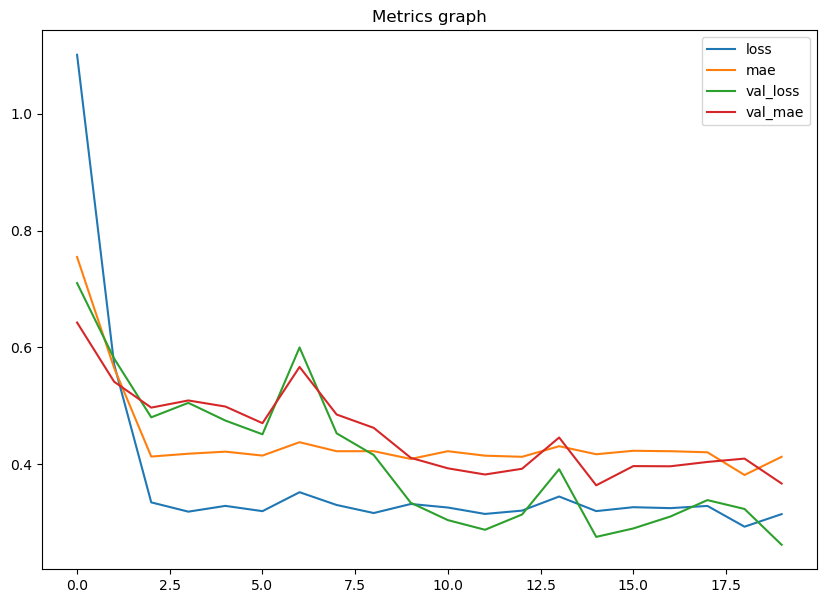

In [8]:
pd.DataFrame(history.history).plot(figsize=(10,7))
plt.title("Metrics graph")
plt.show()

In [9]:
y_pred_scaled = model.predict(x_test_scaled)
y_pred = scaler.inverse_transform(y_pred_scaled)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


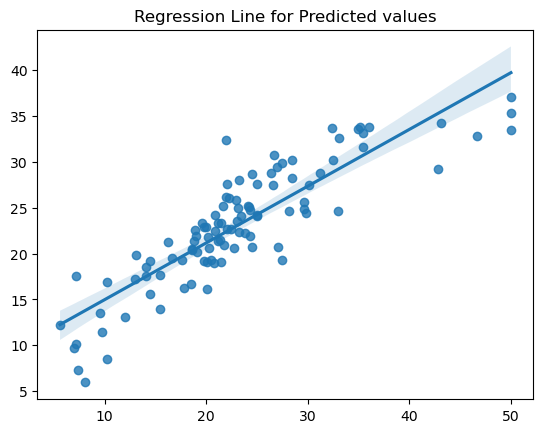

In [10]:
sns.regplot(x=y_test,y=y_pred)
plt.title("Regression Line for Predicted values")
plt.show()

In [12]:
def regression_metrics_display(y_test, y_pred):
     print("MAE is", metrics.mean_absolute_error(y_test, y_pred))
     print("MSE is", metrics.mean_squared_error(y_test, y_pred))
     print("R2 score is", metrics.r2_score(y_test, y_pred))
    
regression_metrics_display(y_test, y_pred)

MAE is 3.3730556787229053
MSE is 22.146824237348696
R2 score is 0.7339524225374932
